In [9]:
import math


ARM_LENGTH = 5.0
ARM_MASS = 5.0

STARTING_ARM_THETA = math.radians(45) # in rad

GRAVITY = -9.8
FRICTION = 0.1

DT = 0.001


class System:

    def __init__(self, arm_length, arm_mass, arm_theta):

        self.arm_length = arm_length
        self.arm_mass = arm_mass
        self.arm_theta = arm_theta

        
        self.arm_moment = 1/3 * (self.arm_mass * self.arm_length**2)
        self.arm_torque = self.arm_mass * self.arm_length/2 * GRAVITY * math.sin(self.arm_theta)

        
        self.arm_atheta = 3/(2 * self.arm_length) * GRAVITY * math.sin(self.arm_theta)
        self.arm_vtheta = 0


        self.arm_thetas = []
        self.arm_vthetas = []
        self.arm_athetas = []



    def solve_for_theta(self):
        
        self.arm_moment = 1/3 * (self.arm_mass * self.arm_length**2)
        self.arm_torque = self.arm_mass * self.arm_length/2 * GRAVITY * math.sin(self.arm_theta)

        
        self.arm_atheta = (self.arm_torque + FRICTION * (-1 if self.arm_vtheta > 0 else 1)) / self.arm_moment
        self.arm_vtheta = self.arm_vtheta + self.arm_atheta * DT
        self.arm_theta = self.arm_theta + self.arm_vtheta * DT


        self.arm_athetas.append(self.arm_atheta)
        self.arm_vthetas.append(self.arm_vtheta)
        self.arm_thetas.append(self.arm_theta)


    def loop(self):
        for i in range(100000):
            self.solve_for_theta()





In [10]:
pendulum = System(ARM_LENGTH, ARM_MASS, STARTING_ARM_THETA)
pendulum.loop()

In [11]:
pendulum.arm_thetas[-1]

-0.44807076409464236

saved -> pendulum.gif  (400 frames @ 30 fps = 13.3s of playback, covering 100s of sim time)


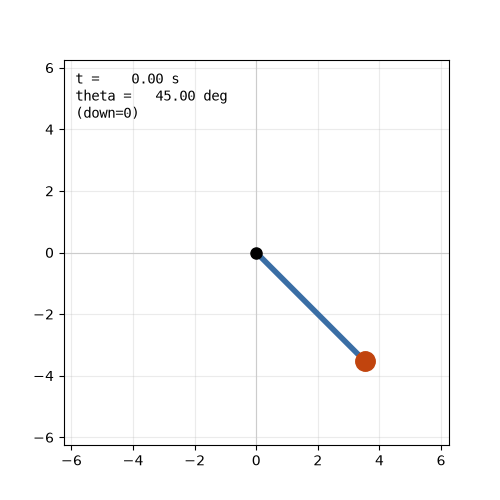

'pendulum.gif'

In [12]:
from viz import animate_pendulum

# inline HTML5 player in Jupyter:
animate_pendulum(pendulum.arm_thetas, arm_length=ARM_LENGTH,
                 units='rad', zero_ref='down', dt=DT)